In [1]:
# security simulation for PoS mining
# goal: analyze attack feasibility based on stake concentration
import numpy as np
import matplotlib.pyplot as plt

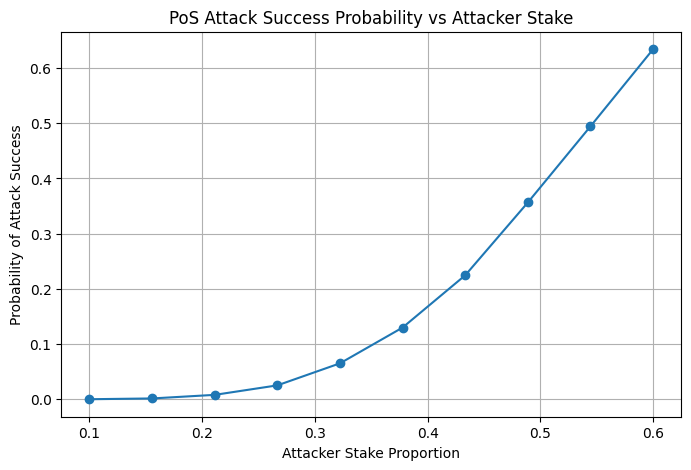

In [ ]:
# v1 simulation
# ignores blockchain history/chain growth/validator selection based on stake

def simulate_pos_attack(num_validators=10000, attack_stake=0.3, num_simulations=10000):
    """
    Simulates attack probability in a PoS system.
    - num_validators: Number of total validators in the network.
    - attack_stake: Fraction of total stake controlled by the attacker.
    - num_simulations: Number of Monte Carlo simulations.
    """
    
    stake_distribution = np.ones(num_validators) / num_validators
    num_attackers = int(num_validators * attack_stake)
    stake_distribution[:num_attackers] = attack_stake / num_attackers
    stake_distribution[num_attackers:] = (1 - attack_stake) / (num_validators - num_attackers)
    
    attack_success_count = 0
    
    for _ in range(num_simulations):
        selected_validators = np.random.choice(range(num_validators), size=10, p=stake_distribution, replace=True)
        
        if np.sum(selected_validators < num_attackers) > 5:
            attack_success_count += 1
    
    attack_probability = attack_success_count / num_simulations
    return attack_probability

attack_stakes = np.linspace(0.1, 0.6, 10)
attack_probs = [simulate_pos_attack(attack_stake=stake) for stake in attack_stakes]

plt.figure(figsize=(8, 5))
plt.plot(attack_stakes, attack_probs, marker='o', linestyle='-')
plt.xlabel('Attacker Stake Proportion')
plt.ylabel('Probability of Attack Success')
plt.title('PoS Attack Success Probability vs Attacker Stake')
plt.show()

In [ ]:
# next todo: compare this to PoW attack probability
# sustainabilty of PoS

# if we assume num_validators is 10000 we have
num_validators = 10000
energy_per_txn = 50 #kWh; assume 15 transactions per second 
#https://www.bitwave.io/blog/is-proof-of-stake-really-more-energy-efficient-than-proof-of-work#:~:text=Ethereum%20can%20conduct%20around%2015,or%20sourcing%20large%20energy%20supplies.”

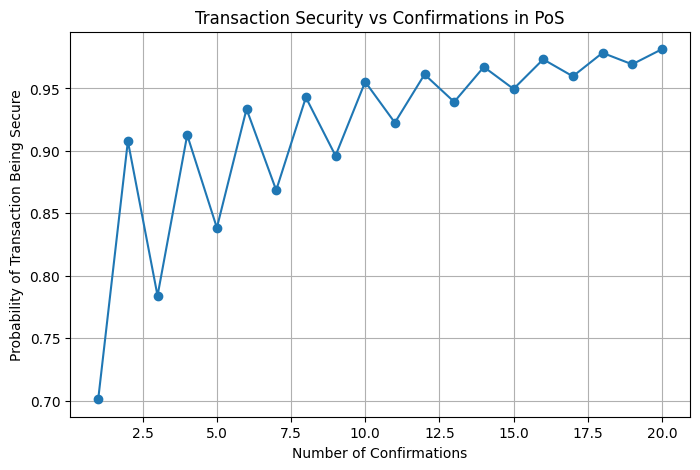

In [7]:
def simulate_transaction_security(num_confirmations=10, attack_stake=0.3, num_simulations=10000):
    """
    Simulates the probability that a transaction remains irreversible after a given number of confirmations.
    - num_confirmations: Number of blocks added after the transaction.
    - attack_stake: Fraction of total stake controlled by the attacker.
    - num_simulations: Number of Monte Carlo simulations.
    """
    
    attack_success_count = 0
    
    for _ in range(num_simulations):
        attacker_blocks = np.sum(np.random.rand(num_confirmations) < attack_stake)
        
        if attacker_blocks > num_confirmations / 2:
            attack_success_count += 1
    
    attack_probability = attack_success_count / num_simulations
    return attack_probability

confirmations = np.arange(1, 21)
security_probs = [1 - simulate_transaction_security(num_confirmations=n) for n in confirmations]

plt.figure(figsize=(8, 5))
plt.plot(confirmations, security_probs, marker='o', linestyle='-')
plt.xlabel('Number of Confirmations')
plt.ylabel('Probability of Transaction Being Secure')
plt.title('Transaction Security vs Confirmations in PoS')
plt.grid()
plt.show()